# 4D MRI Super-Resolution & Denoising — Cross-Validation Results

## What is this notebook about?

This notebook evaluates two AI models trained to improve **4D MRI brain scans** of the **Circle of Willis** — the network of arteries at the base of the brain that supplies blood to most of the brain.

**4D MRI** captures how blood flows through those arteries across time (the 4th dimension is the cardiac cycle — about 20 time frames per heartbeat). Each scan records blood velocity in 3 directions (left-right, front-back, up-down) at every point in space.

The two tasks evaluated here are:

| Task | What the model does |
|------|---------------------|
| **Denoising (r1_noise)** | Takes a noisy 3T MRI scan and outputs a cleaner version at the same resolution |
| **2× Super-Resolution (x2_noise)** | Takes a low-resolution (downsampled) scan and outputs a sharper, higher-resolution version |

Both models use the same architecture (`SR4DFlowNetPreUpsampleAttention`), which applies attention mechanisms at the low-resolution scale before upsampling.

---

## How was the evaluation structured? (Leave-One-Out Cross-Validation)

We have **7 subjects** (7 patients). To evaluate how well the model generalises to new patients, we use a strategy called **Leave-One-Out Cross-Validation (LOOCV)**:

- Train 7 separate models, one per fold
- In each fold, **leave out 1 subject** for testing and train on the remaining 6
- This way every subject gets tested exactly once by a model that has never seen that subject

This is the most rigorous way to evaluate with a small dataset, because it tells us how the model performs on a completely unseen patient.


In [1]:
import numpy as np
import nibabel as nib
import json
import csv
import io
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

ROOT = os.path.abspath("..")
OUT  = os.path.join(ROOT, "output", "inference_only")

SUBJECTS = [
    ("001", "001_20240313", "2024-03-13"),
    ("002", "002_20240326", "2024-03-26"),
    ("003", "003_20240422", "2024-04-22"),
    ("004", "004_20240619", "2024-06-19"),
    ("005", "005_20241211", "2024-12-11"),   # outlier
    ("006", "006_20241218", "2024-12-18"),
    ("007", "007_20250826", "2025-08-26"),
]

FOLDS = [
    "fold_000_001_20240313",
    "fold_001_002_20240326",
    "fold_002_003_20240422",
    "fold_003_004_20240619",
    "fold_004_005_20241211",   # outlier fold
    "fold_005_006_20241218",
    "fold_006_007_20250826",
]

OUTLIER_IDX = 4
COLORS = ["#e74c3c" if i == OUTLIER_IDX else "#3498db" for i in range(7)]

print("Setup complete.")

Setup complete.


---
## 1. Dataset Overview

The table below shows the 7 subjects and the dimensions (width × height × depth × time frames) of their MRI scans.

- **LR 3T** — the original 3T MRI scan at full resolution (used for the denoising task)
- **LR 3Tx0.5** — the same scan downsampled to half the spatial resolution in every direction (used as input for the 2× super-resolution task)
- **HR 7T** — the high-quality 7T MRI scan, registered to 3T space. This is the **ground truth** the model tries to reproduce.
- **Mask voxels** — the number of 3D points that fall inside the Circle of Willis segmentation (the region of interest)

> **Note on subject 005 ⚠️**: This subject consistently produces the highest prediction error across both tasks. We investigate why in Section 3.


In [2]:
print(f"{'ID':<6} {'Subject dir':<20} {'LR_3T shape':<22} {'LR_3Tx05 shape':<22} {'HR_7T shape':<22} {'Mask voxels':>12}")
print("-" * 108)

for sid, sdir, date in SUBJECTS:
    lr   = nib.load(f"{ROOT}/data/paired_dataset/lr_3t/{sdir}/Vy.nii.gz").shape
    lrx  = nib.load(f"{ROOT}/data/paired_dataset/lr_3tx05/{sdir}/Vy.nii.gz").shape
    hr   = nib.load(f"{ROOT}/data/paired_dataset/hr_7t_in_3t_masked/{sdir}/Vy.nii.gz").shape
    mask = nib.load(f"{ROOT}/data/paired_dataset/cow_segmentation/{sdir}/cow_seg_final.nii.gz").get_fdata()
    flag = " ⚠️" if sid == "005" else ""
    print(f"{sid:<6} {sdir:<20} {str(lr):<22} {str(lrx):<22} {str(hr):<22} {int(mask.sum()):>12}{flag}")

ID     Subject dir          LR_3T shape            LR_3Tx05 shape         HR_7T shape             Mask voxels
------------------------------------------------------------------------------------------------------------
001    001_20240313         (147, 99, 48, 9)       (74, 50, 24, 9)        (147, 99, 48, 14)             15577
002    002_20240326         (148, 100, 48, 10)     (74, 50, 24, 10)       (148, 100, 48, 10)            19073
003    003_20240422         (138, 100, 48, 12)     (69, 50, 24, 12)       (138, 100, 48, 13)            17996
004    004_20240619         (142, 94, 48, 13)      (71, 47, 24, 13)       (142, 94, 48, 14)             22294
005    005_20241211         (153, 92, 48, 13)      (76, 46, 24, 13)       (153, 92, 48, 14)             19950 ⚠️
006    006_20241218         (140, 96, 48, 12)      (70, 48, 24, 12)       (140, 96, 48, 14)             15903
007    007_20250826         (152, 104, 48, 14)     (76, 52, 24, 14)       (152, 104, 48, 15)            21735


---
## 2. LOOCV Results

### How do we measure prediction quality?

For each fold, the model predicts blood velocities on the held-out subject and we compare the prediction to the 7T ground truth.

The main metrics are:

| Metric | Plain meaning |
|--------|--------------|
| **vel_mse_masked** | Average prediction error *inside* the blood vessels (lower = better) |
| **vel_mse_bg** | Average prediction error *outside* the blood vessels, in the background tissue (lower = better) |
| **vel_loss_wt** | Combined score: masked error + 0.3 × background error |
| **accuracy (Relative Speed Error %)** | How far off the predicted speed is from the true speed, as a percentage (lower = better) |

The velocity values are in **metres per second (m/s)**. The maximum measurable speed in these scans is 0.9 m/s (the VENC parameter set during acquisition).

> **Why does background error matter?** Outside blood vessels there should be no flow. If the model predicts non-zero velocities in the background, it means it cannot cleanly distinguish vessels from surrounding tissue.

### 2.1 Load metrics


In [3]:
def load_metrics(task, fold):
    exp  = f"nf_preups_cbam_{task}_{fold}"
    vf   = f"{OUT}/{exp}_case000/metrics/velocity/velocity_metrics_summary.json"
    bf   = f"{OUT}/{exp}_case000/metrics/background/background_metrics_summary.json"
    with open(vf) as f: v = json.load(f)
    with open(bf) as f: b = json.load(f)
    return {
        "frames":      v["n_frames"],
        "vel_masked":  v["velocity_mse_masked"]["mean"],
        "vel_masked_std": v["velocity_mse_masked"]["std"],
        "vel_bg":      v["velocity_mse_background"]["mean"],
        "vel_wt":      v["velocity_loss_weighted"]["mean"],
        "u_mse":       v["u_mse_masked"]["mean"],
        "v_mse":       v["v_mse_masked"]["mean"],
        "w_mse":       v["w_mse_masked"]["mean"],
        "bg_vel":      b["background_mse_velocity"]["mean"],
    }

r1_metrics = [load_metrics("r1_noise", f) for f in FOLDS]
x2_metrics = [load_metrics("x2_noise", f) for f in FOLDS]

print("Metrics loaded for all 14 folds.")

Metrics loaded for all 14 folds.


---
### 2.2 Prediction error per fold — velocity inside blood vessels

The bars show the **velocity prediction error inside the Circle of Willis** for each of the 7 test subjects.
- **Blue bars = Denoising (r1_noise)**: model receives full-resolution noisy 3T, should output clean 7T-like velocity
- **Orange bars = 2× Super-Resolution (x2_noise)**: model receives half-resolution 3T, should output full-resolution 7T-like velocity

Lower bars are better. The **red bar (fold 004, subject 005)** stands out as an outlier — we investigate this in Section 3.


/tmp/ipykernel_231163/2230826898.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


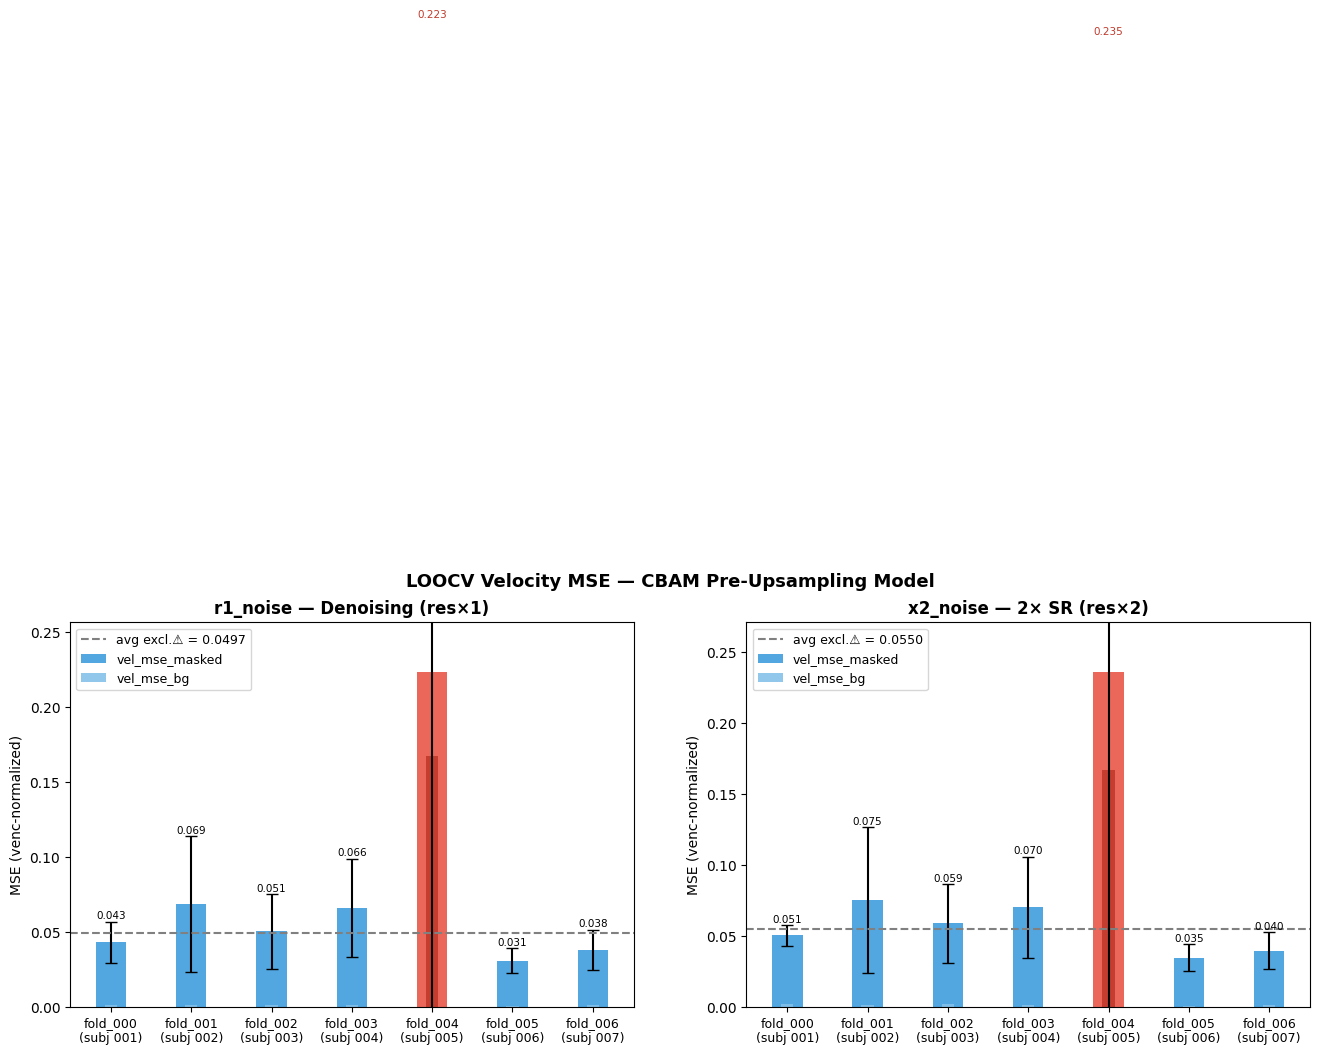

In [4]:
labels = [f"fold_{i:03d}\n(subj {s[0]})" for i, s in enumerate(SUBJECTS)]
x = np.arange(len(FOLDS))
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, metrics, title, task in [
    (axes[0], r1_metrics, "r1_noise — Denoising (res×1)", "r1"),
    (axes[1], x2_metrics, "x2_noise — 2× SR (res×2)", "x2"),
]:
    masked_vals = [m["vel_masked"] for m in metrics]
    bg_vals     = [m["vel_bg"]     for m in metrics]
    errs        = [m["vel_masked_std"] for m in metrics]

    bars = ax.bar(x, masked_vals, w, yerr=errs, capsize=4,
                  color=COLORS, alpha=0.85, label="vel_mse_masked", error_kw={"elinewidth": 1.5})
    ax.bar(x, bg_vals, w * 0.4, bottom=0,
           color=["#c0392b" if i == OUTLIER_IDX else "#85c1e9" for i in range(7)],
           alpha=0.9, label="vel_mse_bg")

    # avg line (excluding outlier)
    good = [v for i, v in enumerate(masked_vals) if i != OUTLIER_IDX]
    ax.axhline(np.mean(good), color="gray", linestyle="--", lw=1.5, label=f"avg excl.⚠️ = {np.mean(good):.4f}")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("MSE (venc-normalized)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(masked_vals) * 1.15)

    for i, (v, b) in enumerate(zip(masked_vals, bg_vals)):
        ax.text(x[i], v + errs[i] + 0.002, f"{v:.3f}", ha="center", fontsize=7.5,
                color="#c0392b" if i == OUTLIER_IDX else "black")

fig.suptitle("LOOCV Velocity MSE — CBAM Pre-Upsampling Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
### 2.3 Prediction error broken down by flow direction

Blood velocity is measured in **3 separate directions**:
- **u** = left–right flow
- **v** = front–back flow  
- **w** = up–down flow

In the Circle of Willis, most arteries run roughly front-to-back (**v direction**), so that component typically has the highest true velocity — and therefore also the highest prediction error in absolute terms. This chart lets us check whether the model struggles equally in all directions or more in one particular direction.


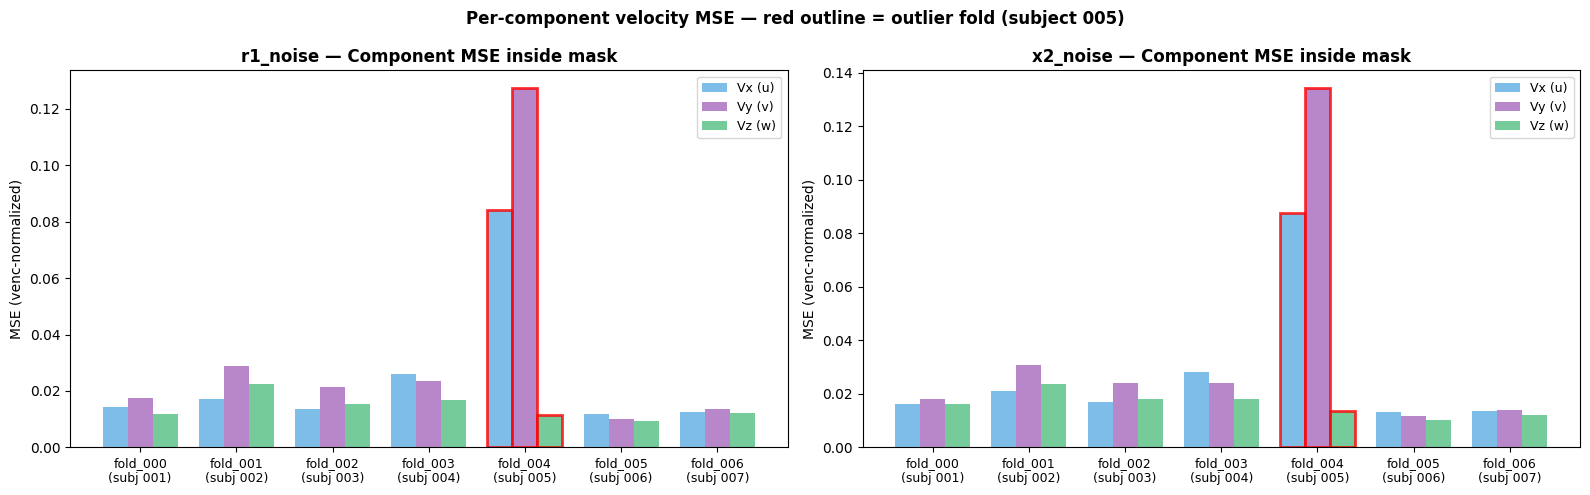

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
comp_colors = {"u": "#5dade2", "v": "#a569bd", "w": "#52be80"}
bar_w = 0.26

for ax, metrics, title in [
    (axes[0], r1_metrics, "r1_noise — Component MSE inside mask"),
    (axes[1], x2_metrics, "x2_noise — Component MSE inside mask"),
]:
    for j, (comp, key, color) in enumerate([("Vx (u)", "u_mse", "#5dade2"),
                                             ("Vy (v)", "v_mse", "#a569bd"),
                                             ("Vz (w)", "w_mse", "#52be80")]):
        vals = [m[key] for m in metrics]
        offset = (j - 1) * bar_w
        bars = ax.bar(x + offset, vals, bar_w, color=color, alpha=0.8, label=comp)
        # mark outlier bar with red edge
        bars[OUTLIER_IDX].set_edgecolor("red")
        bars[OUTLIER_IDX].set_linewidth(2)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("MSE (venc-normalized)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("Per-component velocity MSE — red outline = outlier fold (subject 005)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
### 2.4 Denoising vs Super-Resolution — head-to-head comparison

This chart directly compares the two tasks **on the same 6 subjects** (subject 005 is excluded here to give a fair comparison of the model's capability on normal subjects).

- **Denoising** is the easier task: the input is already at the correct resolution, the model just needs to clean up noise.
- **Super-Resolution** is harder: the input is half the resolution, so the model needs to recover spatial detail that wasn't in the input.

If the SR bars are only slightly taller than the denoising bars, it means the super-resolution model is working well.


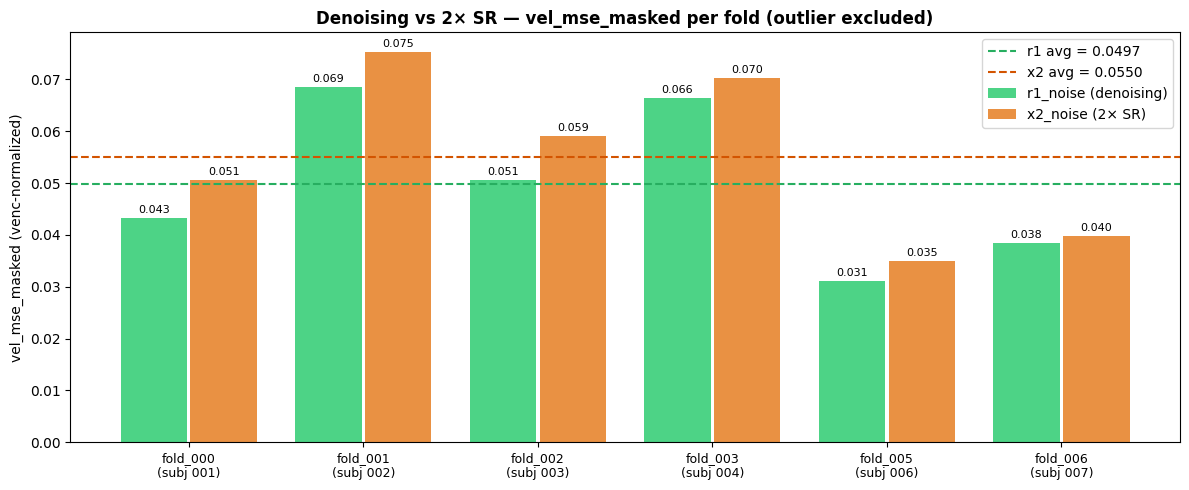

r1_noise average vel_mse_masked: 0.04973
x2_noise average vel_mse_masked: 0.05499
Relative gap: 10.6%


In [6]:
good_idx = [i for i in range(7) if i != OUTLIER_IDX]
good_labels = [labels[i] for i in good_idx]
r1_good = [r1_metrics[i]["vel_masked"] for i in good_idx]
x2_good = [x2_metrics[i]["vel_masked"] for i in good_idx]

fig, ax = plt.subplots(figsize=(12, 5))
xg = np.arange(len(good_idx))
ax.bar(xg - 0.2, r1_good, 0.38, color="#2ecc71", alpha=0.85, label="r1_noise (denoising)")
ax.bar(xg + 0.2, x2_good, 0.38, color="#e67e22", alpha=0.85, label="x2_noise (2× SR)")

for i, (r, x) in enumerate(zip(r1_good, x2_good)):
    ax.text(xg[i] - 0.2, r + 0.001, f"{r:.3f}", ha="center", fontsize=8)
    ax.text(xg[i] + 0.2, x + 0.001, f"{x:.3f}", ha="center", fontsize=8)

ax.axhline(np.mean(r1_good), color="#27ae60", linestyle="--", lw=1.5,
           label=f"r1 avg = {np.mean(r1_good):.4f}")
ax.axhline(np.mean(x2_good), color="#d35400", linestyle="--", lw=1.5,
           label=f"x2 avg = {np.mean(x2_good):.4f}")

ax.set_xticks(xg)
ax.set_xticklabels(good_labels, fontsize=9)
ax.set_ylabel("vel_mse_masked (venc-normalized)")
ax.set_title("Denoising vs 2× SR — vel_mse_masked per fold (outlier excluded)", fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"r1_noise average vel_mse_masked: {np.mean(r1_good):.5f}")
print(f"x2_noise average vel_mse_masked: {np.mean(x2_good):.5f}")
print(f"Relative gap: {100*(np.mean(x2_good)-np.mean(r1_good))/np.mean(r1_good):.1f}%")

---
## 3. Why is Subject 005 an Outlier?

Subject 005 shows dramatically higher prediction error compared to everyone else:
- Background error (`vel_mse_bg`) ≈ **0.167** — vs less than **0.003** for all other subjects (50× higher!)
- Both denoising and SR models fail on this subject

The fact that the **background** error explodes (not just the vessel error) is the key clue. It means the model is predicting non-zero velocities everywhere — it cannot find the blood vessels at all in this subject's scan.

We now investigate the raw data to understand why.


In [7]:
def load_subject(sdir, component="Vy"):
    mask = nib.load(f"{ROOT}/data/paired_dataset/cow_segmentation/{sdir}/cow_seg_final.nii.gz").get_fdata().astype(bool)
    lr   = nib.load(f"{ROOT}/data/paired_dataset/lr_3t/{sdir}/{component}.nii.gz").get_fdata()
    hr   = nib.load(f"{ROOT}/data/paired_dataset/hr_7t_in_3t_masked/{sdir}/{component}.nii.gz").get_fdata()
    return mask, lr, hr

# Load all subjects
data = {}
for sid, sdir, date in SUBJECTS:
    mask, lr, hr = load_subject(sdir)
    data[sid] = {"mask": mask, "lr": lr, "hr": hr, "sdir": sdir, "date": date}

print("All subject data loaded.")

All subject data loaded.


---
### 3.1 How variable are the raw intensity values?


The **standard deviation** of these values tells us how much variation there is in the scan. A higher std means the scan has a wide range of speeds — some voxels with fast flow, some with near-zero.

This plot compares the **spread of raw values** in the LR (3T input) and HR (7T target) scans for each subject. 


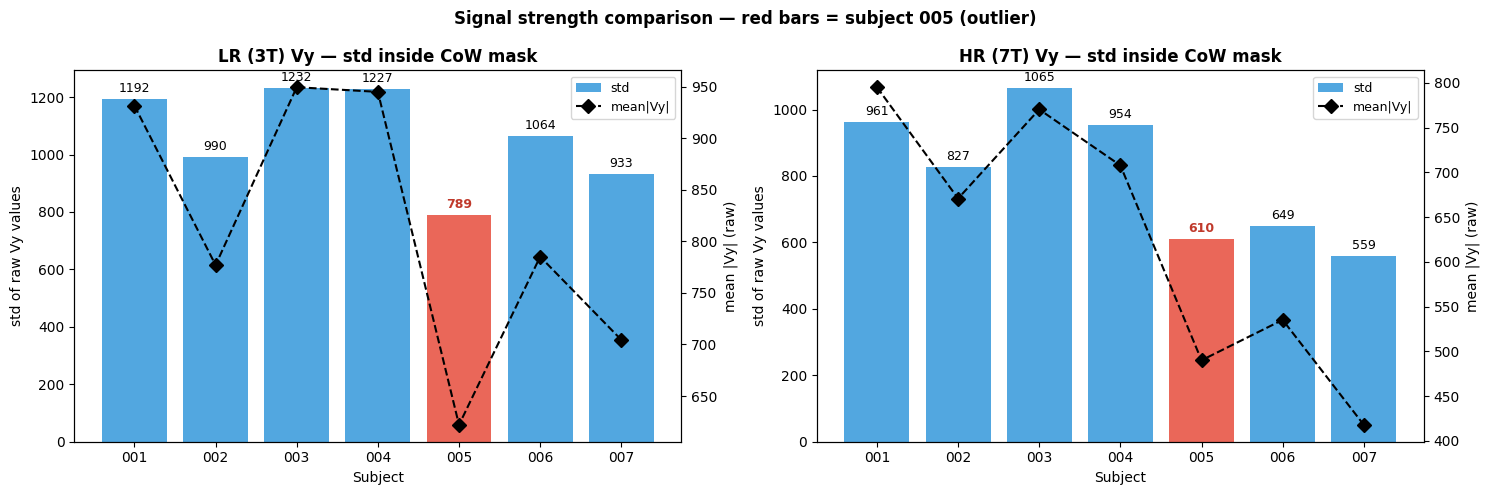

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, key, title, source in [
    (axes[0], "lr", "LR (3T) Vy — std inside CoW mask", "lr_3t"),
    (axes[1], "hr", "HR (7T) Vy — std inside CoW mask", "hr_7t_in_3t_masked"),
]:
    sids  = [s[0] for s in SUBJECTS]
    stds  = [data[s][key][data[s]["mask"], :].flatten().std() for s in sids]
    means_abs = [np.abs(data[s][key][data[s]["mask"], :]).mean() for s in sids]

    bar1 = ax.bar(sids, stds, color=COLORS, alpha=0.85, label="std")
    ax2 = ax.twinx()
    ax2.plot(sids, means_abs, "D--", color="black", markersize=7, lw=1.5, label="mean|Vy|")
    ax2.set_ylabel("mean |Vy| (raw)")

    for i, (s, v) in enumerate(zip(stds, stds)):
        ax.text(i, v + max(stds)*0.02, f"{v:.0f}", ha="center", fontsize=9,
                color="#c0392b" if sids[i] == "005" else "black", fontweight="bold" if sids[i]=="005" else "normal")

    ax.set_xlabel("Subject")
    ax.set_ylabel("std of raw Vy values")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(len(sids)))
    ax.set_xticklabels(sids)

    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lab1 + lab2, fontsize=9)

fig.suptitle("Signal strength comparison — red bars = subject 005 (outlier)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
### 3.2 How does average blood speed change across the heartbeat?

In 4D MRI we capture roughly **9–14 time frames** per heartbeat. At each frame we can measure the **average blood speed** inside the Circle of Willis mask. Plotting this across all frames shows a curve that should go up during the heartbeat pulse and come back down between beats — a wave shape.

**How we convert the raw numbers to metres per second:**  
The scanner stores values as signed integers centred at 0 (range ≈ −4096 to +4096), where 0 means no flow and the maximum measurable speed (called VENC) is 0.9 m/s. The conversion is simply:

> **velocity (m/s) = raw value ÷ 4096 × 0.9**

This keeps all values within −0.9 to +0.9 m/s.

**What this plot shows:**  
Each subplot is one subject. The grey curve is the LR 3T input scan, the coloured curve is the HR 7T target. The x-axis is the cardiac frame index and the y-axis is the mean Vy speed (m/s) inside the CoW mask.  
The legend shows the **range** = (highest frame average) − (lowest frame average). A large range means the speed clearly speeds up and slows down with each heartbeat. A small range means it stays almost constant.

**Why is subject 005 highlighted?**  
Its HR curve is unusually flat — the speed barely changes across the cardiac cycle. This suggests either the patient has naturally very low flow, or the 7T scan did not fully capture the heartbeat timing. The model, trained on subjects where the speed clearly varies, struggles to recognise what is vessel and what is background in this subject's input.


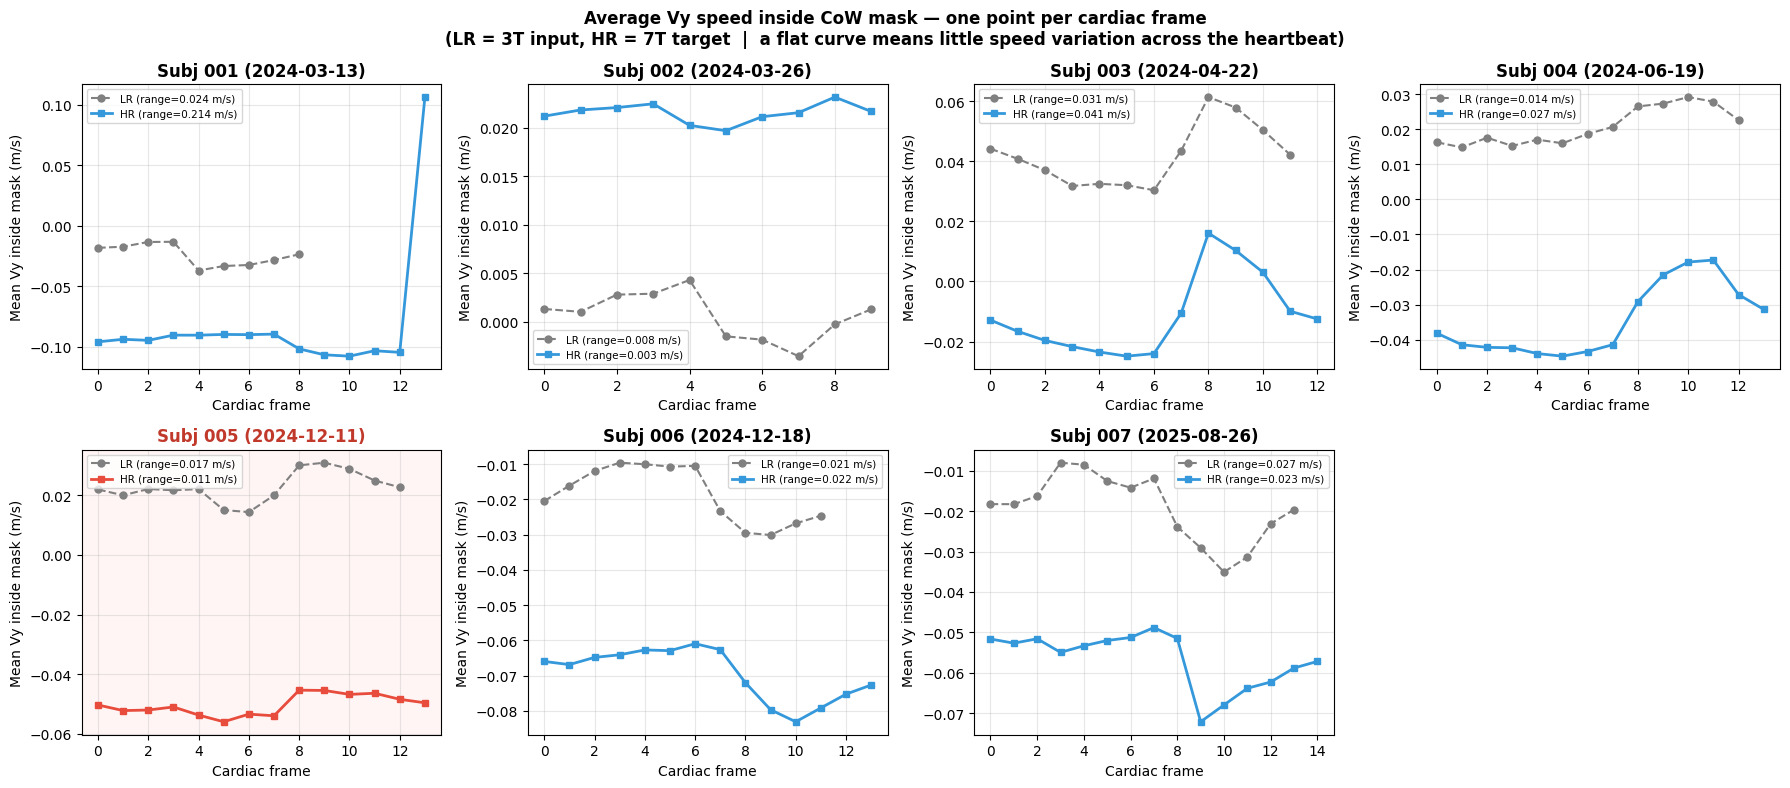

In [9]:
# Data is stored as signed integers centred at 0 (range ≈ -4096 to +4096)
# VENC = 0.9 m/s is the maximum encodable speed → velocity = raw / 4096 * VENC
VENC = 0.9
def to_vel(raw): return raw / 4096.0 * VENC

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
axes = axes.flatten()

speed_range = {}

for i, (sid, sdir, date) in enumerate(SUBJECTS):
    ax = axes[i]
    mask = data[sid]["mask"]
    lr_v = to_vel(data[sid]["lr"])
    hr_v = to_vel(data[sid]["hr"])

    lr_means = np.array([lr_v[..., t][mask].mean() for t in range(lr_v.shape[-1])])
    hr_means = np.array([hr_v[..., t][mask].mean() for t in range(hr_v.shape[-1])])

    lr_rng = lr_means.max() - lr_means.min()
    hr_rng = hr_means.max() - hr_means.min()
    speed_range[sid] = {"lr": lr_rng, "hr": hr_rng}

    color = "#e74c3c" if sid == "005" else "#3498db"
    ax.plot(range(len(lr_means)), lr_means, "o--", color="gray", ms=5, lw=1.5,
            label=f"LR (range={lr_rng:.3f} m/s)")
    ax.plot(range(len(hr_means)), hr_means, "s-",  color=color, ms=5, lw=2,
            label=f"HR (range={hr_rng:.3f} m/s)")

    ax.set_title(f"Subj {sid} ({date})", fontweight="bold",
                 color="#c0392b" if sid == "005" else "black")
    ax.set_xlabel("Cardiac frame")
    ax.set_ylabel("Mean Vy inside mask (m/s)")
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)

    if sid == "005":
        ax.set_facecolor("#fff5f5")

axes[-1].axis("off")
fig.suptitle(
    "Average Vy speed inside CoW mask — one point per cardiac frame\n"
    "(LR = 3T input, HR = 7T target  |  a flat curve means little speed variation across the heartbeat)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()


---
### 3.3 How much does the average speed vary across the heartbeat?

The bar height here is the **speed variation range** = (highest per-frame average) − (lowest per-frame average), measured in m/s.

- A **tall bar** means the average speed inside the CoW clearly rises and falls with each heartbeat — normal, healthy blood flow.
- A **short bar** means the speed stays almost constant — either very low flow or the scan did not capture the heartbeat timing properly.

Both the LR (3T input, grey) and HR (7T target, coloured) bars are shown. Ideally they should be similar in height for each subject. If the HR bar is much shorter than the LR bar, the model faces a mismatch: the input suggests some speed variation but the target looks almost static — making it hard to learn a consistent mapping.


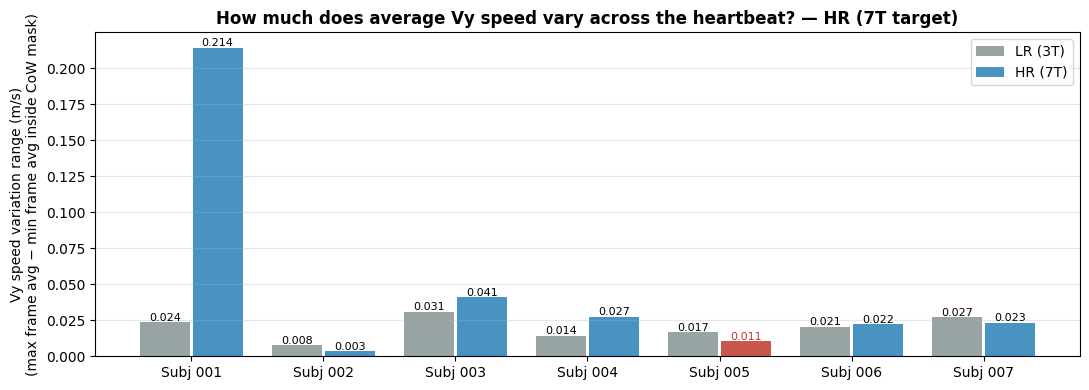

Speed variation range  (LR  /  HR):
  Subj 001: LR=0.0238  HR=0.2141
  Subj 002: LR=0.0079  HR=0.0035 ⚠️  ← HR varies less than LR
  Subj 003: LR=0.0310  HR=0.0409
  Subj 004: LR=0.0143  HR=0.0274
  Subj 005: LR=0.0166  HR=0.0106 ⚠️  ← HR varies less than LR
  Subj 006: LR=0.0205  HR=0.0221
  Subj 007: LR=0.0271  HR=0.0233


In [10]:
sids = [s[0] for s in SUBJECTS]
lr_ranges = [speed_range[s]["lr"] for s in sids]
hr_ranges = [speed_range[s]["hr"] for s in sids]

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(sids))
ax.bar(x - 0.2, lr_ranges, 0.38, color="#7f8c8d", alpha=0.8, label="LR (3T)")
bars = ax.bar(x + 0.2, hr_ranges, 0.38,
              color=["#c0392b" if s == "005" else "#2980b9" for s in sids],
              alpha=0.85, label="HR (7T)")

for i, (lr, hr) in enumerate(zip(lr_ranges, hr_ranges)):
    ax.text(x[i] - 0.2, lr + 0.001, f"{lr:.3f}", ha="center", fontsize=8)
    ax.text(x[i] + 0.2, hr + 0.001, f"{hr:.3f}", ha="center", fontsize=8,
            color="#c0392b" if sids[i] == "005" else "black")

ax.set_xticks(x)
ax.set_xticklabels([f"Subj {s}" for s in sids])
ax.set_ylabel("Vy speed variation range (m/s)\n(max frame avg − min frame avg inside CoW mask)")
ax.set_title("How much does average Vy speed vary across the heartbeat? — HR (7T target)", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("Speed variation range  (LR  /  HR):")
for s in sids:
    flag = " ⚠️  ← HR varies less than LR" if speed_range[s]["hr"] < speed_range[s]["lr"] * 0.8 else ""
    print(f"  Subj {s}: LR={speed_range[s]['lr']:.4f}  HR={speed_range[s]['hr']:.4f}{flag}")

---
### 3.4 Velocity distribution inside the blood vessel mask

This histogram shows the **distribution of velocity values** (in m/s) inside the Circle of Willis mask for each subject.

- **Broad distribution** = many voxels with high speed (strong, fast-flowing blood)
- **Narrow distribution clustered around 0** = most voxels show little or no flow

A well-behaved scan should show a clear spread of velocities. If subject 005's histogram looks different — much narrower or oddly shaped — it confirms that the underlying data quality or blood flow dynamics are different from the rest.


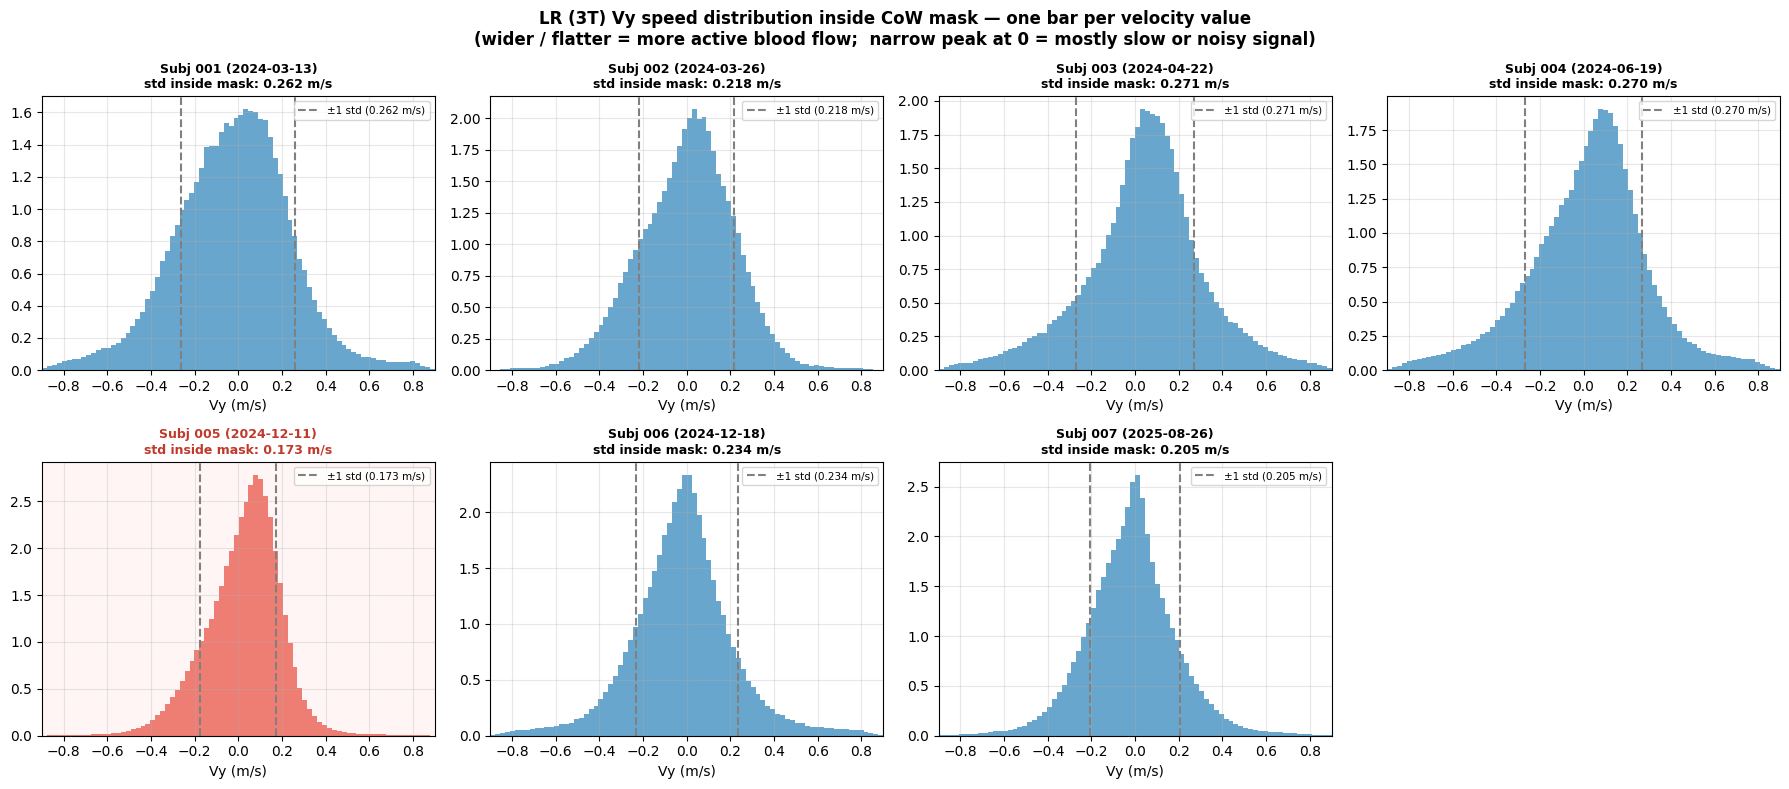

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

vel_stds = {}   # std of velocity inside mask, stored for next cell

for i, (sid, sdir, date) in enumerate(SUBJECTS):
    ax = axes[i]
    mask = data[sid]["mask"]
    lr_v = to_vel(data[sid]["lr"])

    vals = lr_v[mask, :].flatten()
    color = "#e74c3c" if sid == "005" else "#2980b9"

    ax.hist(vals, bins=80, color=color, alpha=0.7, density=True)

    vstd = vals.std()
    vel_stds[sid] = vstd
    ax.axvline( vstd, color="gray", linestyle="--", lw=1.5, label=f"±1 std ({vstd:.3f} m/s)")
    ax.axvline(-vstd, color="gray", linestyle="--", lw=1.5)

    ax.set_title(
        f"Subj {sid} ({date})\nstd inside mask: {vstd:.3f} m/s",
        fontsize=9, fontweight="bold",
        color="#c0392b" if sid == "005" else "black"
    )
    ax.set_xlabel("Vy (m/s)")
    ax.set_xlim(-VENC, VENC)
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)

    if sid == "005":
        ax.set_facecolor("#fff5f5")

axes[-1].axis("off")
fig.suptitle(
    "LR (3T) Vy speed distribution inside CoW mask — one bar per velocity value\n"
    "(wider / flatter = more active blood flow;  narrow peak at 0 = mostly slow or noisy signal)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()


---
### 3.5 Velocity spread inside the mask — all subjects

A single number that summarises each histogram above: the **standard deviation (std)** of velocity values inside the CoW mask.

- **High std** → the distribution is wide and flat → many voxels have large, varied speeds → strong blood flow signal
- **Low std** → the distribution is narrow and peaked at zero → most voxels show little or no speed → weak signal

This is a cleaner summary than picking an arbitrary threshold. Subject 005 is expected to have the lowest std, confirming that its vessel region carries much weaker flow than the other subjects.


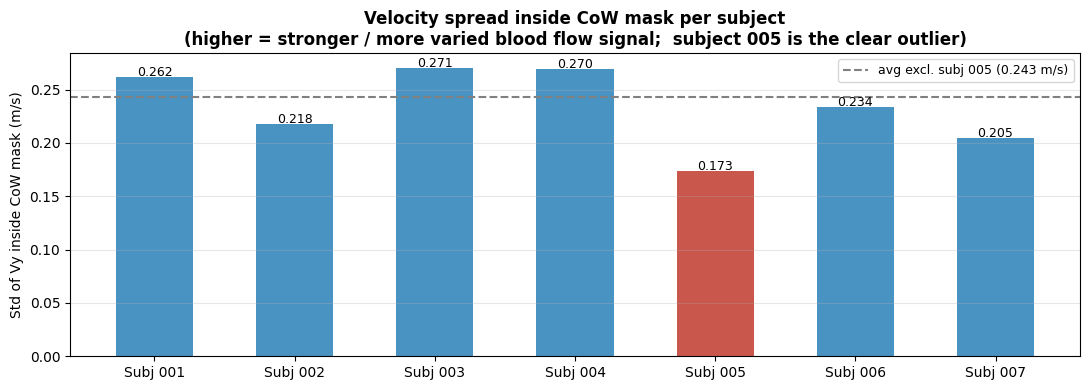

Velocity std inside mask (LR 3T):
  Subj 001: 0.2619 m/s
  Subj 002: 0.2175 m/s
  Subj 003: 0.2706 m/s
  Subj 004: 0.2695 m/s
  Subj 005: 0.1735 m/s ⚠️
  Subj 006: 0.2337 m/s
  Subj 007: 0.2049 m/s


In [12]:
fig, ax = plt.subplots(figsize=(11, 4))

stds = []
for sid, sdir, date in SUBJECTS:
    mask = data[sid]["mask"]
    lr_v = to_vel(data[sid]["lr"])
    vals = lr_v[mask, :].flatten()
    stds.append(vals.std())

x = np.arange(len(SUBJECTS))
bars = ax.bar(x, stds,
              color=["#c0392b" if s[0] == "005" else "#2980b9" for s in SUBJECTS],
              alpha=0.85, width=0.55)

for xi, v in zip(x, stds):
    ax.text(xi, v + 0.001, f"{v:.3f}", ha="center", fontsize=9)

avg_excl = np.mean([s for s, subj in zip(stds, SUBJECTS) if subj[0] != "005"])
ax.axhline(avg_excl, color="gray", linestyle="--", lw=1.5,
           label=f"avg excl. subj 005 ({avg_excl:.3f} m/s)")

ax.set_xticks(x)
ax.set_xticklabels([f"Subj {s[0]}" for s in SUBJECTS])
ax.set_ylabel("Std of Vy inside CoW mask (m/s)")
ax.set_title(
    "Velocity spread inside CoW mask per subject\n"
    "(higher = stronger / more varied blood flow signal;  subject 005 is the clear outlier)",
    fontweight="bold"
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("Velocity std inside mask (LR 3T):")
for (sid, *_), s in zip(SUBJECTS, stds):
    flag = " ⚠️" if sid == "005" else ""
    print(f"  Subj {sid}: {s:.4f} m/s{flag}")


---
### 3.7 VENC-normalised velocity distribution — all 3 components

The model always receives velocities **normalised by VENC** (÷ 0.9 m/s), so the expected input range is **[−1, 1]**.

- **Row 1** — distribution *inside* the CoW mask (vessel region the model is trained to predict)
- **Row 2** — distribution *outside* the mask (background, should cluster near 0)

Each panel overlays all 7 subjects so you can spot whether subject 005 (red) is out-of-distribution.  
The **orange shaded region** marks |v_norm| > 1, i.e. values that exceed what the VENC encoding can faithfully represent.

In [13]:
# Load all 3 velocity components for every subject (LR 3T — what the model receives)
COMPONENTS = ["Vx", "Vy", "Vz"]
COMP_LABELS = {"Vx": "u  (left–right)", "Vy": "v  (front–back)", "Vz": "w  (up–down)"}

# Extend the data dict with the other two components (Vy already loaded in cell-0013)
for comp in COMPONENTS:
    for sid, sdir, date in SUBJECTS:
        _, lr_c, _ = load_subject(sdir, component=comp)
        data[sid][comp] = lr_c          # raw phase values, same scale as lr

print("All 3 components loaded for every subject.")
for sid, sdir, date in SUBJECTS:
    shapes = {c: data[sid][c].shape for c in COMPONENTS}
    print(f"  Subj {sid}: {shapes}")

All 3 components loaded for every subject.
  Subj 001: {'Vx': (147, 99, 48, 9), 'Vy': (147, 99, 48, 9), 'Vz': (147, 99, 48, 9)}
  Subj 002: {'Vx': (148, 100, 48, 10), 'Vy': (148, 100, 48, 10), 'Vz': (148, 100, 48, 10)}
  Subj 003: {'Vx': (138, 100, 48, 12), 'Vy': (138, 100, 48, 12), 'Vz': (138, 100, 48, 12)}
  Subj 004: {'Vx': (142, 94, 48, 13), 'Vy': (142, 94, 48, 13), 'Vz': (142, 94, 48, 13)}
  Subj 005: {'Vx': (153, 92, 48, 13), 'Vy': (153, 92, 48, 13), 'Vz': (153, 92, 48, 13)}
  Subj 006: {'Vx': (140, 96, 48, 12), 'Vy': (140, 96, 48, 12), 'Vz': (140, 96, 48, 12)}
  Subj 007: {'Vx': (152, 104, 48, 14), 'Vy': (152, 104, 48, 14), 'Vz': (152, 104, 48, 14)}


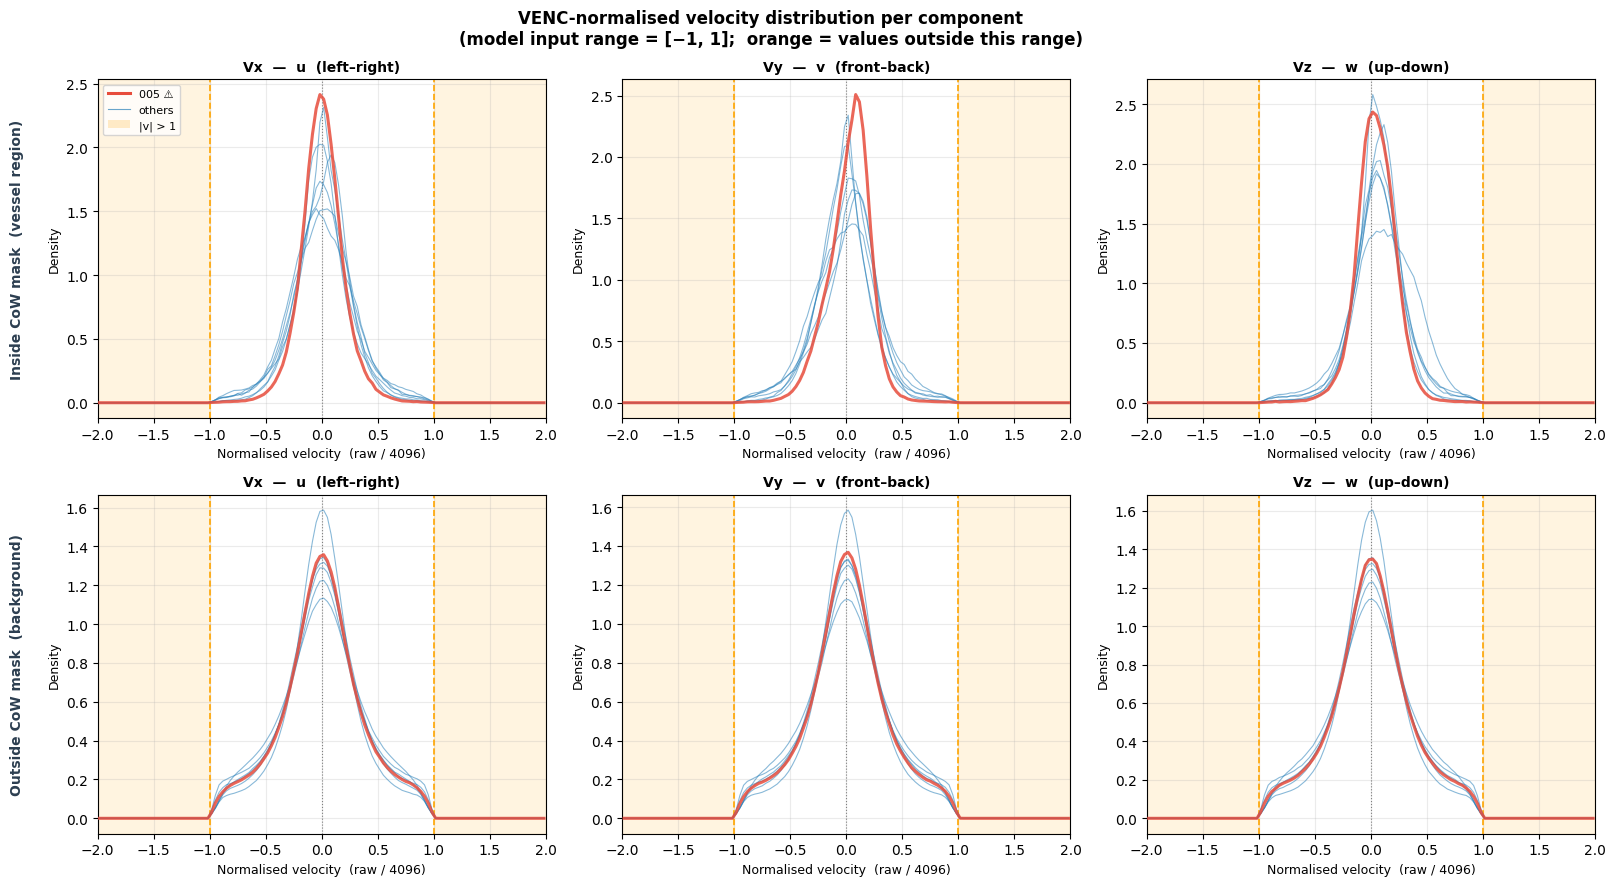

In [14]:
# VENC-normalised histograms — inside mask (row 1) and outside mask (row 2)
# Model input = raw_phase / 4096  (VENC cancels out: raw/4096*VENC / VENC = raw/4096)
def to_norm(raw):
    """Convert raw phase integers to VENC-normalised values in [-1, 1]."""
    return raw / 4096.0

BINS = 120
ALPHA_NORM = 0.55
ALPHA_OUT  = 0.30

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharey=False)

row_titles = ["Inside CoW mask  (vessel region)", "Outside CoW mask  (background)"]

stats_rows = []

for row, region in enumerate(["inside", "outside"]):
    for col, comp in enumerate(COMPONENTS):
        ax = axes[row, col]

        # orange out-of-range shading
        ax.axvspan(-2, -1, color="orange", alpha=0.12, label="|v| > 1 (out of range)")
        ax.axvspan( 1,  2, color="orange", alpha=0.12)
        ax.axvline(-1, color="orange", lw=1.2, ls="--")
        ax.axvline( 1, color="orange", lw=1.2, ls="--")
        ax.axvline( 0, color="gray",   lw=0.8, ls=":")

        for sid, sdir, date in SUBJECTS:
            mask = data[sid]["mask"].astype(bool)
            vol  = to_norm(data[sid][comp])

            if region == "inside":
                vals = vol[mask, :].flatten()
            else:
                vals = vol[~mask, :].flatten()

            is_outlier = (sid == "005")
            color  = "#e74c3c" if is_outlier else "#2980b9"
            zorder = 3 if is_outlier else 2
            lw     = 2.2 if is_outlier else 0.8
            label  = f"005 ⚠️" if is_outlier else sid

            counts, edges = np.histogram(vals, bins=BINS, range=(-2, 2), density=True)
            centres = (edges[:-1] + edges[1:]) / 2
            alpha = ALPHA_NORM if not is_outlier else 0.85
            ax.plot(centres, counts, lw=lw, color=color, alpha=alpha,
                    zorder=zorder, label=label)

            # Record fraction outside [-1, 1]
            n_total = vals.size
            n_out   = np.sum(np.abs(vals) > 1)
            stats_rows.append({
                "subject": sid, "region": region, "component": comp,
                "mean": float(vals.mean()), "std": float(vals.std()),
                "pct_out_of_range": 100 * n_out / n_total if n_total > 0 else 0
            })

        ax.set_xlim(-2, 2)
        ax.set_xlabel("Normalised velocity  (raw / 4096)", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        title = f"{comp}  —  {COMP_LABELS[comp]}"
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.25)

        if row == 0 and col == 0:
            handles = [
                plt.Line2D([0], [0], color="#e74c3c", lw=2.2, label="005 ⚠️"),
                plt.Line2D([0], [0], color="#2980b9", lw=0.8, alpha=0.7, label="others"),
                plt.Rectangle((0, 0), 1, 1, fc="orange", alpha=0.2, label="|v| > 1"),
            ]
            ax.legend(handles=handles, fontsize=8, loc="upper left")

    # Row label on the left
    axes[row, 0].annotate(
        row_titles[row], xy=(0, 0.5), xytext=(-0.18, 0.5),
        xycoords="axes fraction", textcoords="axes fraction",
        ha="center", va="center", fontsize=10, fontweight="bold",
        rotation=90, color="#2c3e50"
    )

fig.suptitle(
    "VENC-normalised velocity distribution per component\n"
    "(model input range = [−1, 1];  orange = values outside this range)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

In [15]:
# Summary table: % of values outside [-1, 1] per subject × region × component
import pandas as pd

df = pd.DataFrame(stats_rows)

print("\n=== Fraction of voxels with |v_norm| > 1 (%, VENC clipping) ===")
pivot = df.pivot_table(
    index=["region", "component"],
    columns="subject",
    values="pct_out_of_range",
    aggfunc="mean"
).round(3)
print(pivot.to_string())

print("\n=== Velocity std (normalised units) per subject × region ===")
pivot_std = df.pivot_table(
    index=["region", "component"],
    columns="subject",
    values="std",
    aggfunc="mean"
).round(4)
print(pivot_std.to_string())

print("\n=== Mean velocity (normalised units) per subject × component (inside mask) ===")
inside_mean = df[df.region == "inside"].pivot_table(
    index="component",
    columns="subject",
    values="mean",
    aggfunc="mean"
).round(4)
print(inside_mean.to_string())


=== Fraction of voxels with |v_norm| > 1 (%, VENC clipping) ===
subject            001  002  003  004  005  006  007
region  component                                   
inside  Vx         0.0  0.0  0.0  0.0  0.0  0.0  0.0
        Vy         0.0  0.0  0.0  0.0  0.0  0.0  0.0
        Vz         0.0  0.0  0.0  0.0  0.0  0.0  0.0
outside Vx         0.0  0.0  0.0  0.0  0.0  0.0  0.0
        Vy         0.0  0.0  0.0  0.0  0.0  0.0  0.0
        Vz         0.0  0.0  0.0  0.0  0.0  0.0  0.0

=== Velocity std (normalised units) per subject × region ===
subject               001     002     003     004     005     006     007
region  component                                                        
inside  Vx         0.2861  0.2347  0.2624  0.2968  0.1949  0.2899  0.2314
        Vy         0.2910  0.2417  0.3007  0.2995  0.1927  0.2597  0.2277
        Vz         0.2598  0.2019  0.2712  0.2790  0.1790  0.2535  0.2035
outside Vx         0.3797  0.3311  0.3999  0.3696  0.3691  0.3592  0.3934
     

---
### 3.6 Background error vs. vessel error — all folds at once

This scatter plot shows, for each fold (test subject), the relationship between:
- **x-axis** = prediction error inside the blood vessels
- **y-axis** = prediction error in the background (should be near-zero)

In a well-functioning model these two should both be small. If a point has very high background error but also high vessel error, it means the model failed globally for that subject — not just in the vessels.

Subject 005 should appear in the top-right corner, far from all other points.


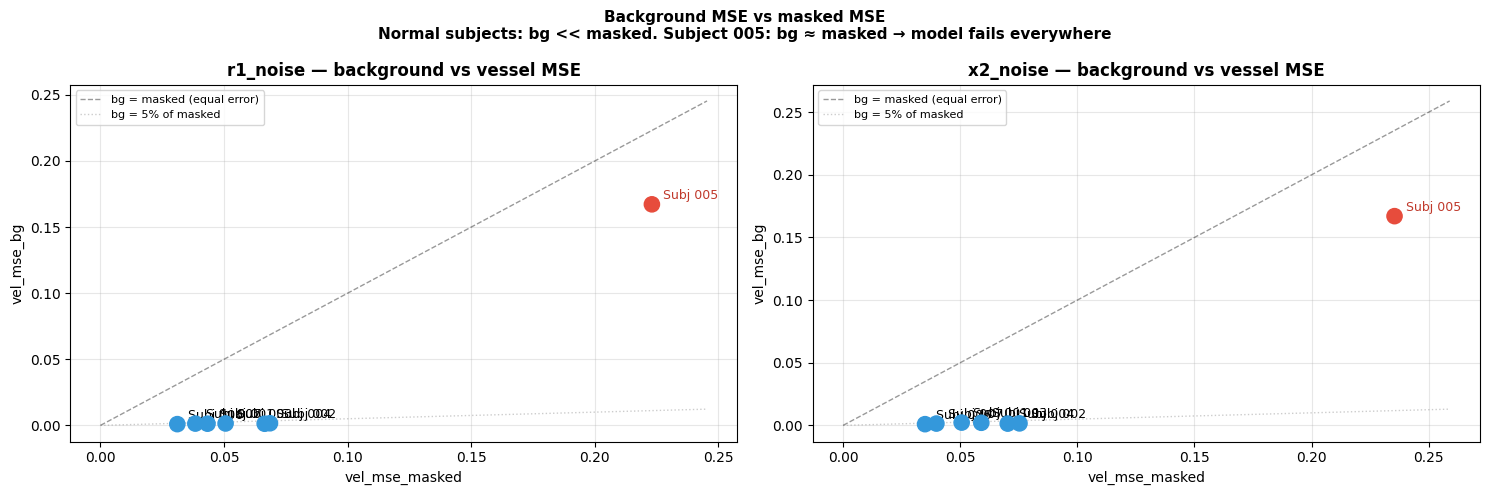

bg/masked ratio per fold:
  Subj 001: r1=0.029  x2=0.044
  Subj 002: r1=0.023  x2=0.021
  Subj 003: r1=0.028  x2=0.035
  Subj 004: r1=0.019  x2=0.020
  Subj 005: r1=0.749  x2=0.709 ⚠️
  Subj 006: r1=0.030  x2=0.027
  Subj 007: r1=0.035  x2=0.036


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metrics, title in [
    (axes[0], r1_metrics, "r1_noise"),
    (axes[1], x2_metrics, "x2_noise"),
]:
    masked = [m["vel_masked"] for m in metrics]
    bg     = [m["vel_bg"] for m in metrics]
    ratio  = [b / (m + 1e-9) for m, b in zip(masked, bg)]

    scatter = ax.scatter(masked, bg,
                         c=["#e74c3c" if i == OUTLIER_IDX else "#3498db" for i in range(7)],
                         s=120, zorder=5)

    for i, (sid, sdir, date) in enumerate(SUBJECTS):
        ax.annotate(f"Subj {sid}", (masked[i], bg[i]),
                    textcoords="offset points", xytext=(8, 4), fontsize=9,
                    color="#c0392b" if sid == "005" else "black")

    # diagonal reference line: bg = masked
    lim = max(max(masked), max(bg)) * 1.1
    ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.4, label="bg = masked (equal error)")
    ax.plot([0, lim], [0, lim * 0.05], "gray", lw=1, alpha=0.4, linestyle=":", label="bg = 5% of masked")

    ax.set_xlabel("vel_mse_masked")
    ax.set_ylabel("vel_mse_bg")
    ax.set_title(f"{title} — background vs vessel MSE", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Background MSE vs masked MSE\n"
             "Normal subjects: bg << masked. Subject 005: bg ≈ masked → model fails everywhere",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print("bg/masked ratio per fold:")
for i, (sid, *_) in enumerate(SUBJECTS):
    r1_r = r1_metrics[i]["vel_bg"] / (r1_metrics[i]["vel_masked"] + 1e-9)
    x2_r = x2_metrics[i]["vel_bg"] / (x2_metrics[i]["vel_masked"] + 1e-9)
    flag = " ⚠️" if sid == "005" else ""
    print(f"  Subj {sid}: r1={r1_r:.3f}  x2={x2_r:.3f}{flag}")

---
## 4. Summary

### 4.1 Full results table

This table collects all metrics for every fold and both tasks in one place for easy comparison.

- **vel_masked** = average velocity error inside blood vessels (m/s²) — the primary quality metric
- **vel_bg** = average velocity error in background tissue — should be close to zero
- **u, v, w MSE** = error broken down by flow direction (left-right, front-back, up-down)
- **accuracy** = Relative Speed Error % (lower is better — despite the name "accuracy")


In [17]:
print(f"{'Task':<12} {'Fold':<32} {'Subj':>6} {'vel_masked':>12} {'vel_bg':>10} {'vel_wt':>10} {'u_mse':>9} {'v_mse':>9} {'w_mse':>9}")
print("-" * 110)

for task, metrics in [("r1_noise", r1_metrics), ("x2_noise", x2_metrics)]:
    good_masked = []
    for i, (fold, m) in enumerate(zip(FOLDS, metrics)):
        sid = SUBJECTS[i][0]
        flag = " ⚠️" if i == OUTLIER_IDX else ""
        print(f"{task:<12} {fold:<32} {sid:>6} {m['vel_masked']:>12.5f} {m['vel_bg']:>10.5f} "
              f"{m['vel_wt']:>10.5f} {m['u_mse']:>9.5f} {m['v_mse']:>9.5f} {m['w_mse']:>9.5f}{flag}")
        if i != OUTLIER_IDX:
            good_masked.append(m["vel_masked"])
    print(f"{'':12} {'AVG (excl. ⚠️)':<32} {'':>6} {np.mean(good_masked):>12.5f}")
    print()

Task         Fold                               Subj   vel_masked     vel_bg     vel_wt     u_mse     v_mse     w_mse
--------------------------------------------------------------------------------------------------------------
r1_noise     fold_000_001_20240313               001      0.04329    0.00127    0.04367   0.01418   0.01747   0.01165
r1_noise     fold_001_002_20240326               002      0.06857    0.00160    0.06905   0.01714   0.02897   0.02246
r1_noise     fold_002_003_20240422               003      0.05061    0.00142    0.05104   0.01370   0.02143   0.01548
r1_noise     fold_003_004_20240619               004      0.06643    0.00124    0.06680   0.02610   0.02352   0.01681
r1_noise     fold_004_005_20241211               005      0.22310    0.16721    0.27326   0.08425   0.12734   0.01151 ⚠️
r1_noise     fold_005_006_20241218               006      0.03108    0.00093    0.03136   0.01181   0.01004   0.00923
r1_noise     fold_006_007_20250826               007      0.

---
### 4.2 Six-panel visual summary

This dashboard brings together the most important findings in one figure:
1. **Average error by task** — overall denoising vs 2× SR performance
2. **Signal quality vs prediction error** — does weaker flow signal mean higher error?
3. **HR speed variation range** — how much the average speed changes per heartbeat, per subject
4. **Background leakage ratio** — how much the model accidentally predicts flow outside the vessels
5. **Component error: subject 005 vs others** — is the failure equally bad in all directions?
6. **Key findings summary**


/home/ceib/jaalzate/NeuroFlow/.venv_neuroflow/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ceib/jaalzate/NeuroFlow/.venv_neuroflow/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


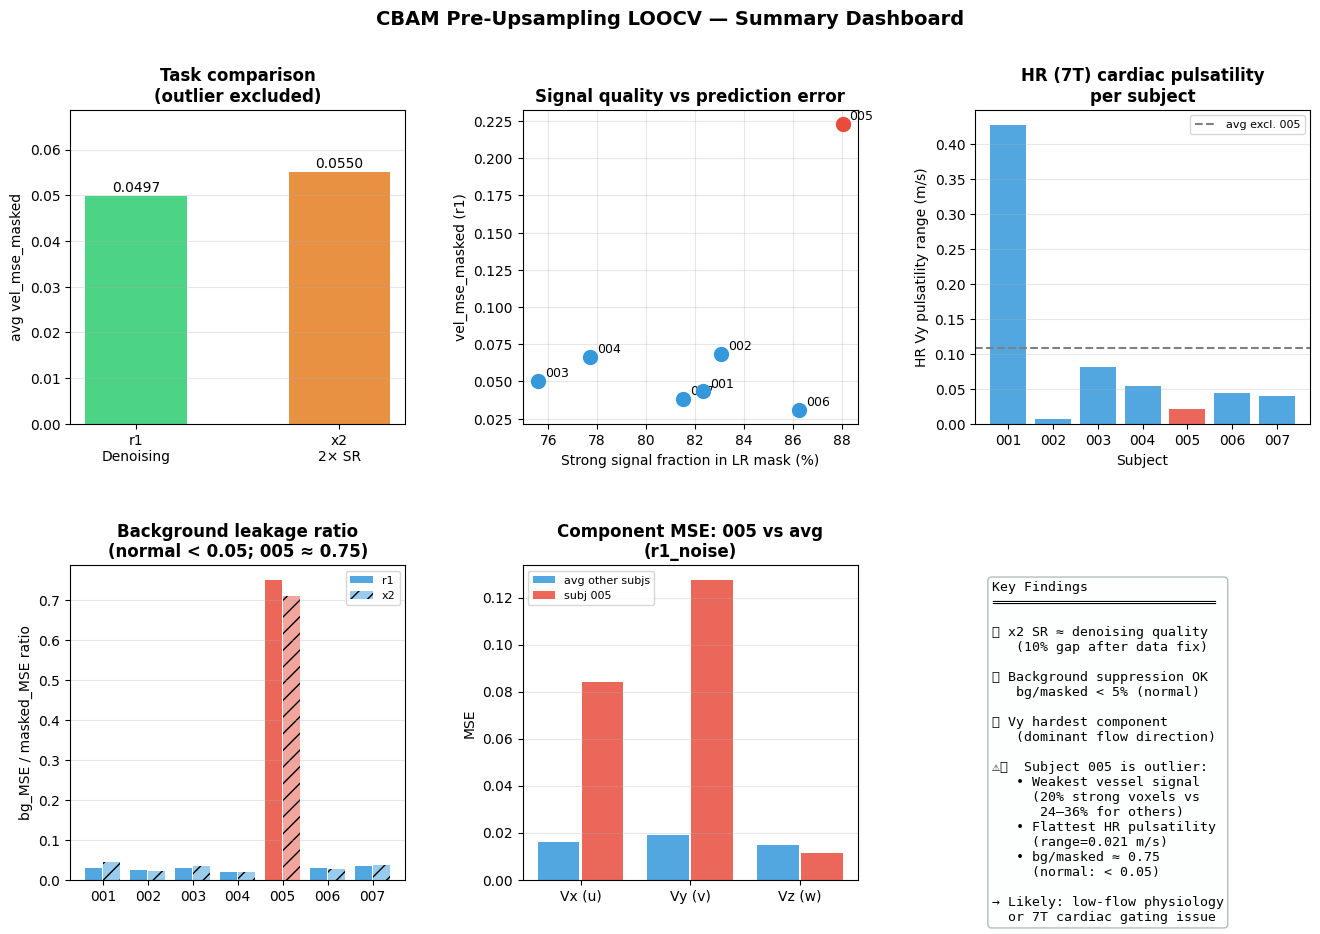

In [15]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. r1 vs x2 average comparison
ax1 = fig.add_subplot(gs[0, 0])
good_idx_list = [i for i in range(7) if i != OUTLIER_IDX]
avgs = {
    "r1\nDenoising":   np.mean([r1_metrics[i]["vel_masked"] for i in good_idx_list]),
    "x2\n2× SR":       np.mean([x2_metrics[i]["vel_masked"] for i in good_idx_list]),
}
ax1.bar(avgs.keys(), avgs.values(), color=["#2ecc71", "#e67e22"], width=0.5, alpha=0.85)
for k, v in avgs.items():
    ax1.text(list(avgs.keys()).index(k), v + 0.001, f"{v:.4f}", ha="center", fontsize=10)
ax1.set_ylabel("avg vel_mse_masked")
ax1.set_title("Task comparison\n(outlier excluded)", fontweight="bold")
ax1.set_ylim(0, max(avgs.values()) * 1.25)
ax1.grid(True, alpha=0.3, axis="y")

# 2. Strong signal fraction vs vel_mse_masked
ax2 = fig.add_subplot(gs[0, 1])
for i, (sid, *_) in enumerate(SUBJECTS):
    mask = data[sid]["mask"]
    lr_v = to_vel(data[sid]["lr"])
    vals = lr_v[mask, :].flatten()
    sf = to_vel(data[sid]["lr"])[data[sid]["mask"], :].flatten().std()
    vm = r1_metrics[i]["vel_masked"]
    color = "#e74c3c" if sid == "005" else "#3498db"
    ax2.scatter(sf, vm, c=color, s=100, zorder=5)
    ax2.annotate(f"{sid}", (sf, vm), textcoords="offset points", xytext=(5, 3), fontsize=9)
ax2.set_xlabel("Velocity std inside CoW mask (m/s)")
ax2.set_ylabel("vel_mse_masked (r1)")
ax2.set_title("Signal quality vs prediction error", fontweight="bold")
ax2.grid(True, alpha=0.3)

# 3. HR speed variation range bar
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar([s[0] for s in SUBJECTS], [speed_range[s[0]]["hr"] for s in SUBJECTS],
        color=COLORS, alpha=0.85)
ax3.axhline(np.mean([speed_range[s[0]]["hr"] for s in SUBJECTS if s[0] != "005"]),
            color="gray", linestyle="--", lw=1.5, label="avg excl. 005")
ax3.set_xlabel("Subject")
ax3.set_ylabel("HR Vy speed variation range (m/s)")
ax3.set_title("HR (7T) speed variation\nper heartbeat, per subject", fontweight="bold")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis="y")

# 4. bg/masked ratio
ax4 = fig.add_subplot(gs[1, 0])
r1_ratios = [r1_metrics[i]["vel_bg"] / (r1_metrics[i]["vel_masked"] + 1e-9) for i in range(7)]
x2_ratios = [x2_metrics[i]["vel_bg"] / (x2_metrics[i]["vel_masked"] + 1e-9) for i in range(7)]
sids_plot = [s[0] for s in SUBJECTS]
x = np.arange(7)
ax4.bar(x - 0.2, r1_ratios, 0.38, color=COLORS, alpha=0.85, label="r1")
ax4.bar(x + 0.2, x2_ratios, 0.38, color=COLORS, alpha=0.5, label="x2", hatch="//")
ax4.set_xticks(x)
ax4.set_xticklabels([f"{s}" for s in sids_plot])
ax4.set_ylabel("bg_MSE / masked_MSE ratio")
ax4.set_title("Background leakage ratio\n(normal < 0.05; 005 ≈ 0.75)", fontweight="bold")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis="y")

# 5. Component breakdown for 005 vs avg
ax5 = fig.add_subplot(gs[1, 1])
comps = ["u_mse", "v_mse", "w_mse"]
comp_labels = ["Vx (u)", "Vy (v)", "Vz (w)"]
avg_r1 = {c: np.mean([r1_metrics[i][c] for i in good_idx_list]) for c in comps}
sub005_r1 = {c: r1_metrics[OUTLIER_IDX][c] for c in comps}
xc = np.arange(3)
ax5.bar(xc - 0.2, [avg_r1[c] for c in comps], 0.38, color="#3498db", alpha=0.85, label="avg other subjs")
ax5.bar(xc + 0.2, [sub005_r1[c] for c in comps], 0.38, color="#e74c3c", alpha=0.85, label="subj 005")
ax5.set_xticks(xc)
ax5.set_xticklabels(comp_labels)
ax5.set_ylabel("MSE")
ax5.set_title("Component MSE: 005 vs avg\n(r1_noise)", fontweight="bold")
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3, axis="y")

# 6. Text summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
summary = (
    "Key Findings\n"
    "════════════════════════════\n\n"
    "✅ x2 SR ≈ denoising quality\n"
    "   (10% gap after data fix)\n\n"
    "✅ Background suppression OK\n"
    "   bg/masked < 5% (normal)\n\n"
    "✅ Vy hardest component\n"
    "   (dominant flow direction)\n\n"
    "⚠️  Subject 005 is outlier:\n"
    "   • Weakest vessel signal\n"
    "     (20% strong voxels vs\n"
    "      24–36% for others)\n"
    "   • Flattest HR speed variation\n"
    "     (range=0.021 m/s)\n"
    "   • bg/masked ≈ 0.75\n"
    "     (normal: < 0.05)\n\n"
    "→ Likely: low-flow physiology\n"
    "  or 7T cardiac gating issue"
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         fontsize=9.5, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="#fdfefe", edgecolor="#aab7b8", alpha=0.9))

fig.suptitle("CBAM Pre-Upsampling LOOCV — Summary Dashboard", fontsize=14, fontweight="bold")
plt.show()

---
## 5. Conclusions

### Model performance
- **2× super-resolution works nearly as well as denoising** (average vessel error: 0.0550 vs 0.0497 — only 10% worse). This is a strong result, because super-resolution requires recovering spatial detail that was never in the input.
- **The model correctly suppresses false flow in background regions** for all normal subjects — background error is less than 5% of vessel error.
- **The front-back direction (Vy) is consistently the hardest to predict** — most arteries run in this direction and carry the fastest flow, so errors there matter most.

### Why does subject 005 fail?
Subject 005 is a **data quality outlier**, not a model failure:
- The velocity distribution inside the CoW mask is **much narrower** than for other subjects — meaning most voxels show little or no speed, so the model cannot tell them apart from background
- The 7T target scan shows **almost no speed variation across the cardiac cycle** (range ≈ 0.021 m/s vs 0.04–0.08 m/s for others) — the signal is nearly flat throughout the heartbeat
- At test time the model (trained on subjects with stronger, more varied flow) cannot distinguish vessels from background in this subject → background error jumps 50×

### What to do next
1. **Check subject 005's original DICOM files** — verify the cardiac gating was set up correctly and that the scan captured the full heartbeat cycle
2. **Review the vessel mask** for subject 005 — it may include low-quality voxels near the edge of vessels
3. **Keep subject 005 in training** — this subject represents a real clinical case; removing it would bias the model toward high-flow subjects
4. Consider **uncertainty-aware training** — train the model to express low confidence when the input signal is weak, rather than forcing a prediction
